<a href="https://colab.research.google.com/github/siyux1927/dllm/blob/main/notebooks/colab_p1_p2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# dLLM 上的 diffu-GRPO：P1 耗时拆解 + P2 log-prob 误差量化

本 notebook 对应 `docs/plan-diffu-grpo.md` 的 P1 与 P2 两个阶段，产出故事线前两幕的数据。

**P1 要回答**：单步训练的时间花在哪儿？采样到底占多少？
**P2 要回答**：把 GRPO 搬到扩散模型上，最大的障碍是 log-prob 没有链式法则可用。
单步近似到底差多少？为什么 clip 范围 ε 必须放宽到 0.5？

运行前请确认：**运行时类型 → 硬件加速器 → A100 GPU**。

> 全程约 40 分钟，其中依赖安装与权重下载约 25 分钟（首次；之后走 Drive 缓存）。

## 0. 环境确认

先确认拿到的是 A100。T4 显存 16GB 装不下 8B 的 bf16 权重。

In [1]:
!nvidia-smi

import torch
print(f"torch {torch.__version__}  cuda={torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"{props.name}  显存 {props.total_memory/1e9:.1f} GB")
    assert props.total_memory > 30e9, "显存不足 30GB，8B 模型的 bf16 权重加激活放不下，请换 A100"

Mon Aug 31 13:00:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 1. 挂载 Drive

`/content` 下的一切随会话消失，所以三类东西都要落到 Drive：

- **HF 缓存**：LLaDA-8B 权重约 16GB，重连后不必重下。
- **结果 JSON 与逐步指标 CSV**：只有几十 KB，直接写 Drive。
  脚本每完成一个阶段就落一次盘，不是等全部跑完——那样在第二档断掉会把第一档一起赔进去。
- **checkpoint**：约 4GB，情况复杂，见第 8 节。

In [2]:
import os
from pathlib import Path

from google.colab import drive

drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/dllm-grpo')
RESULTS = DRIVE_ROOT / 'results'
for sub in ('hf-cache', 'results', 'checkpoints'):
    (DRIVE_ROOT / sub).mkdir(parents=True, exist_ok=True)

os.environ['HF_HOME'] = str(DRIVE_ROOT / 'hf-cache')
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '0'
# tokenizers 的并行分词在 fork 后会告警刷屏，且本项目分词不是瓶颈
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
print(f"HF_HOME = {os.environ['HF_HOME']}")
print(f"结果落点 = {RESULTS}")

Mounted at /content/drive
HF_HOME = /content/drive/MyDrive/dllm-grpo/hf-cache
结果落点 = /content/drive/MyDrive/dllm-grpo/results


## 2. 取代码

两种方式二选一：

- 已经把项目推到 git 远端 → 填 `GIT_URL`
- 还没有 → 把整个项目文件夹上传到 Drive 的 `MyDrive/dllm-grpo/diff`，直接跑本单元

In [3]:
import shutil
import subprocess

GIT_URL = 'https://github.com/siyux1927/dllm'  # 例如 'https://github.com/<you>/diff.git'，留空则从 Drive 复制
PROJECT_DIR = Path('/content/diff')

if PROJECT_DIR.exists():
    shutil.rmtree(PROJECT_DIR)

if GIT_URL:
    subprocess.run(['git', 'clone', '--depth', '1', GIT_URL, str(PROJECT_DIR)], check=True)
else:
    source = DRIVE_ROOT / 'diff'
    assert source.exists(), (
        f"{source} 不存在。请把本地项目文件夹上传到 Drive 的 MyDrive/dllm-grpo/diff，"
        "或在上面填入 GIT_URL。"
    )
    # 复制到本地磁盘再跑：Drive 是网络挂载，随机读写慢，且 import 期间断连会直接报错
    shutil.copytree(source, PROJECT_DIR, ignore=shutil.ignore_patterns(
        '__pycache__', '.git', '.pytest_cache', '*.pyc', 'checkpoints', 'results'))

os.chdir(PROJECT_DIR)
print(f"工作目录 {Path.cwd()}")
print(sorted(p.name for p in PROJECT_DIR.iterdir()))

工作目录 /content/diff
['.git', '.gitignore', 'README.md', 'configs', 'docs', 'environment.yml', 'notebooks', 'pyproject.toml', 'requirements-colab.txt', 'scripts', 'src', 'tests']


## 3. 装依赖

约 5-10 分钟，主要花在 torch 上。

版本是钉死的，有两处容易踩：

- **`transformers` 必须是 4.x**。LLaDA 的 `trust_remote_code` 建模代码写于 4.49 时代，
  5.x 改掉了它依赖的若干内部接口。这类不兼容往往不是干净的报错，
  而是加载到一半出些莫名其妙的属性错误。
- **换 torch 就必须一起换 torchvision**。二者的 C++ 扩展是配对编译的。
  只把 torch 钉到 2.6.0、留着 Colab 预装的 torchvision，`torchvision::nms` 就注册不上；
  而 `transformers.image_utils` 会无条件 import torchvision，
  于是连 `AutoModel` 都加载不了，报错却指向 transformers 内部，完全看不出病因。

下面**不截断 pip 的输出**。装依赖失败如果被 `| tail` 吞掉，
你会带着一个半好不坏的环境往下跑，到加载模型时才炸。

In [4]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-r', 'requirements-colab.txt'],
    capture_output=True, text=True)

tail = result.stdout.strip().split('\n')[-15:]
print('\n'.join(tail))
if result.returncode != 0:
    print('\n--- pip 报错 ---')
    print(result.stderr[-4000:])
    raise SystemExit('依赖安装失败，先修好再往下走')
print('\n依赖安装完成')

    Uninstalling torchvision-0.26.0+cu128:
      Successfully uninstalled torchvision-0.26.0+cu128
  Attempting uninstall: torchaudio
    Found existing installation: torchaudio 2.11.0+cu128
    Uninstalling torchaudio-2.11.0+cu128:
      Successfully uninstalled torchaudio-2.11.0+cu128
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.14.0
    Uninstalling accelerate-1.14.0:
      Successfully uninstalled accelerate-1.14.0
  Attempting uninstall: peft
    Found existing installation: peft 0.20.0
    Uninstalling peft-0.20.0:
      Successfully uninstalled peft-0.20.0

依赖安装完成


In [ ]:
# # 装完必须重启运行时：torch 被换了版本，已经 import 的旧版还留在内存里
# import IPython
# IPython.Application.instance().kernel.do_shutdown(True)

> **重启后从这里继续**，不用重跑上面的单元格（Drive 挂载和文件都还在）。

In [5]:
import os
from pathlib import Path

DRIVE_ROOT = Path('/content/drive/MyDrive/dllm-grpo')
RESULTS = DRIVE_ROOT / 'results'
PROJECT_DIR = Path('/content/diff')
os.environ['HF_HOME'] = str(DRIVE_ROOT / 'hf-cache')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.chdir(PROJECT_DIR)

# check_env 会先验 torchvision 的算子再去 import transformers / trl。
# 顺序是有意的：后者的导入链会踩到 torchvision，一旦踩爆，
# 报出来的是一条指向 transformers 内部的六十行 traceback，看不出真正的病因。
!python scripts/check_env.py

python  3.13.15  (/usr/bin/python3)
  注意：Python 3.13。numpy 1.26.4 没有 cp313 的 wheel，requirements 已按版本分流
  torch          2.6.0+cu124      ok
  transformers   4.49.0           ok
  accelerate     1.4.0            ok
  peft           0.15.1           ok
  datasets       3.3.2            ok
  trl            0.16.0.dev0      ok
  numpy          2.1.3
  torchvision    0.21.0+cu124
  torchaudio     2.6.0+cu124

torch.cuda.is_available() = True

torch 配套包检查
  torchvision    0.21.0+cu124     ok
  torchaudio     2.6.0+cu124      ok
  torchvision 算子  torchvision::nms 可用
2026-08-31 13:10:51.169135: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-31 13:10:51.233938: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU in

## 4. 先跑单测

在碰 GPU 之前先跑一遍 CPU 单测。这一步花 30 秒，能挡掉「代码传上来时缺了文件」
或「装依赖时版本冲突改了行为」这类问题——这些如果留到加载完 8B 模型之后才发现，
浪费的是十几分钟的下载和加载。

单测里的 LoRA `target_modules` 和真实配置用的是同一份，所以「适配器挂不上」在这里就会暴露。

In [6]:
!python -m pytest -q 2>&1 | tail -n 15

........................................................................ [ 42%]
........................................................................ [ 85%]
.........................                                                [100%]


## 5. P1：加载模型 + 耗时拆解

脚本依次做四件事：

1. **装配自检**。确认 LoRA 目标模块真的匹配上了，且改动适配器权重确实改变输出。
   LLaDA 派生自 OLMo，用的是 `attn_out` / `ff_proj` / `ff_out` 而非 Llama 的
   `o_proj` / `gate_proj` / `down_proj`；如果这里报错，照它打印出来的真实模块名改配置即可。
2. **padding 不变性自检**。LLaDA 官方的 generate 是按单条 prompt 写的，从没验证过
   带 padding 的批处理。如果 padding 会泄漏进注意力，同一条 prompt 会因为批内其他
   样本的长度不同而得到不同结果——这种错误不报错，只是让结果不可复现。
3. **生成抽查**。看一眼模型到底输出了什么。
4. **分阶段计时**，并把实测占比和理论前向次数预算对照。

这里在 `diffusion_steps` 的两个取值上各测一遍，因为它有个待定的取舍：

- **64**（当前配置）：completion 长 128，等于每步解 2 个 token。单步便宜，
  但采样占比降到约 52%，P4 的端到端上限只剩 2.1x——而且基线本身已经在并行解码了。
- **128**（对齐 d1 官方）：每步解 1 个 token，是干净的基线。采样占比约 68%，
  P4 上限 3.1x，代价是单步慢约 1.5 倍。

脚本会把两者的单步耗时、采样占比、P4 上限和「跑满 200 步要多久」列成一张表。
拿着这张表再定，比凭直觉定可靠。

首次运行要下载约 16GB 权重（15-20 分钟），之后走 Drive 缓存。两个设定合计约 15 分钟。

In [7]:
!python scripts/run_p1_profile.py \
    --config configs/countdown_base.yaml \
    --warmup 1 --steps 2 \
    --sweep-diffusion-steps 64 128 \
    --out {RESULTS}/p1_profile.json \
    --metrics-csv {RESULTS}/p1_metrics.csv

加载 LLaDA-8B-Instruct
2026-08-31 13:11:29.530268: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-31 13:11:29.592899: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading checkpoint shards: 100% 6/6 [02:19<00:00, 23.28s/it]
LoRA 目标模块: ['q_proj', 'k_proj', 'v_proj', 'attn_out', 'ff_proj', 'up_proj', 'ff_out']
mask_id=126336  eos_token_id=126081
可训练参数 335,544,320 / 总参数 8,686,669,824 (3.863%)
LoRA 存活自检通过：改动适配器权重确实改变了输出

padding 不变性自检
不同 padding 长度下补全位置 logits 的最大差异: 0.4375
  未通过——这是 LLaDA 的已知行为，不是本项目的 bug，也不必去修：
 

### P1 结果可视化

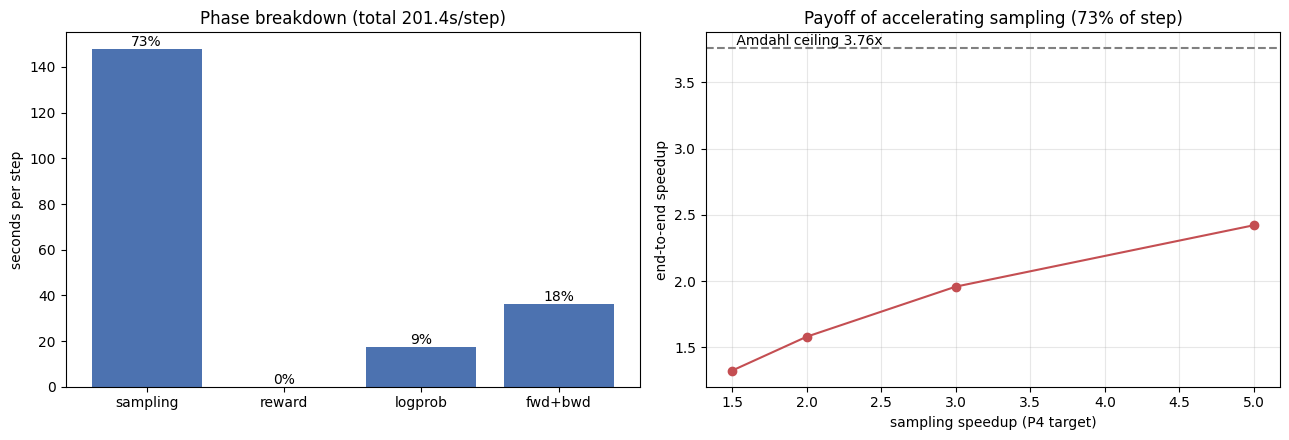

实测采样占比 73.4%   理论预算 68.1%
P4 端到端收益上限 3.76x


In [8]:
import json

import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False

report = json.loads((RESULTS / 'p1_profile.json').read_text(encoding='utf-8'))
timing = report['timing']
budget = report['budget']

phases = ['generation', 'reward', 'logprob', 'forward_backward']
labels = ['sampling', 'reward', 'logprob', 'fwd+bwd']
measured = [timing[f'{p}_frac'] for p in phases]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(labels, [timing[f'{p}_s'] for p in phases], color='#4C72B0')
axes[0].set_ylabel('seconds per step')
axes[0].set_title(f"Phase breakdown (total {timing['total_s']:.1f}s/step)")
for i, p in enumerate(phases):
    axes[0].text(i, timing[f'{p}_s'], f"{timing[f'{p}_frac']:.0%}",
                 ha='center', va='bottom')

ceiling = report['amdahl']['ceiling']
speedups = sorted(float(k[:-1]) for k in report['amdahl']['projections'])
end_to_end = [report['amdahl']['projections'][f'{s:g}x'] for s in speedups]
axes[1].plot(speedups, end_to_end, 'o-', color='#C44E52')
axes[1].axhline(ceiling, ls='--', c='gray')
axes[1].text(speedups[0], ceiling, f' Amdahl ceiling {ceiling:.2f}x', va='bottom')
axes[1].set_xlabel('sampling speedup (P4 target)')
axes[1].set_ylabel('end-to-end speedup')
axes[1].set_title(f"Payoff of accelerating sampling ({measured[0]:.0%} of step)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / 'p1_breakdown.png', dpi=140, bbox_inches='tight')
plt.show()

print(f"实测采样占比 {timing['generation_frac']:.1%}   "
      f"理论预算 {budget['budget/generation_share']:.1%}")
print(f"P4 端到端收益上限 {ceiling:.2f}x")

### 读这张图

左图是第 1 幕的事实：单步时间的分布。右图是从它推出的结论——**P4 到底值不值得做**。

Amdahl 上限是 `1 / (1 - 采样占比)`。如果采样只占一半，那么把采样加速到无穷倍，
端到端也只有 2 倍。这个上限应该在花 A100 之前就算出来，而不是做完 P4 才发现。

### 决策：diffusion_steps 取 64 还是 128

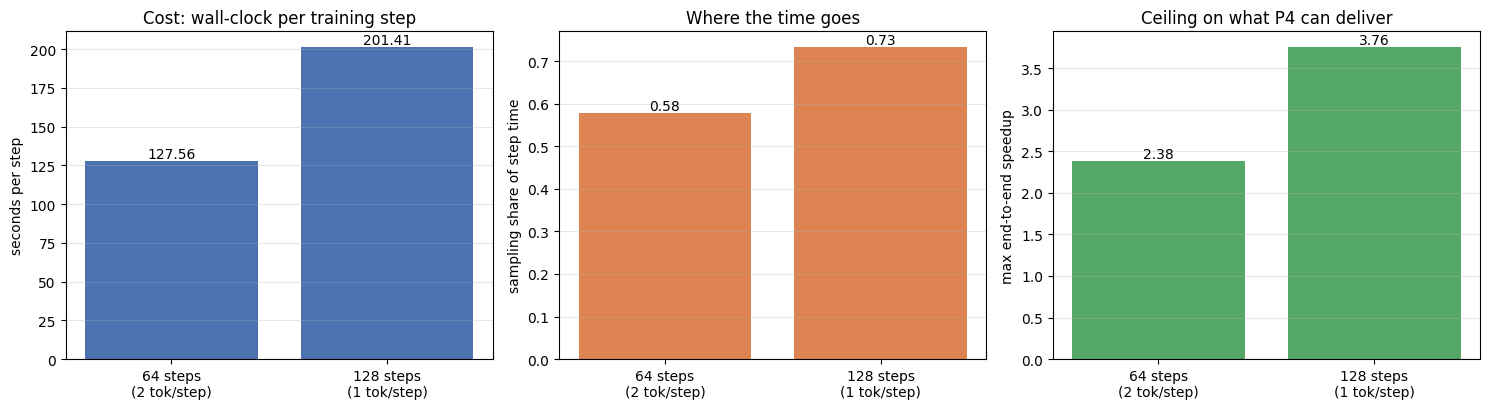

  steps  tok/step  sec/step  sampling  P4 ceiling   200 steps
     64       2.0     127.6    58.0%       2.38x        7.1h
    128       1.0     201.4    73.4%       3.76x       11.2h


In [9]:
sweep = report['sweep']
completion = report['config']['sampling']['max_completion_length']
keys = sorted(sweep, key=int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
x = range(len(keys))
labels = [f"{k} steps\n({completion/int(k):.0f} tok/step)" for k in keys]

axes[0].bar(labels, [sweep[k]['timing']['total_s'] for k in keys], color='#4C72B0')
axes[0].set_ylabel('seconds per step')
axes[0].set_title('Cost: wall-clock per training step')

axes[1].bar(labels, [sweep[k]['timing']['generation_frac'] for k in keys], color='#DD8452')
axes[1].set_ylabel('sampling share of step time')
axes[1].set_title('Where the time goes')

axes[2].bar(labels, [sweep[k]['amdahl']['ceiling'] for k in keys], color='#55A868')
axes[2].set_ylabel('max end-to-end speedup')
axes[2].set_title('Ceiling on what P4 can deliver')

for ax in axes:
    for patch in ax.patches:
        ax.text(patch.get_x() + patch.get_width() / 2, patch.get_height(),
                f'{patch.get_height():.2f}', ha='center', va='bottom')
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(RESULTS / 'p1_diffusion_steps.png', dpi=140, bbox_inches='tight')
plt.show()

print(f"{'steps':>7}{'tok/step':>10}{'sec/step':>10}{'sampling':>10}"
      f"{'P4 ceiling':>12}{'200 steps':>12}")
for k in keys:
    t = sweep[k]['timing']['total_s']
    print(f"{k:>7}{completion/int(k):>10.1f}{t:>10.1f}"
          f"{sweep[k]['timing']['generation_frac']:>9.1%}"
          f"{sweep[k]['amdahl']['ceiling']:>11.2f}x{t*200/3600:>11.1f}h")

### 怎么读这张表

这是个真实的取舍，不是纯优化：

- **每步解码 token 数**大于 1，说明基线本身已经在并行解码了。
  Fast-dLLM 的并行解码收益正是「每步多解几个 token」，
  所以 P4 的加速会有一部分只是把这份预支的收益兑现一次，而不是新增的。
- **P4 上限**是 Amdahl 算出来的天花板。采样占比越低，第 3 幕能讲的东西越少。
- **200 步耗时**决定 P3 能不能跑完。如果这一列超过 5 小时，
  该调的是 `max_steps` 或 `num_prompts_per_step`，而不是硬扛。

三列凑齐了才好定。128 步让第 1、3 幕都更有分量，但如果它把 P3 顶到 8 小时以上，
那就是拿第 5 幕（同等墙钟时间下的 reward 曲线对比）去换第 3 幕，不划算。

## 6. P2：log-prob 近似的误差

自回归模型靠链式法则一次前向拿到序列 log-prob，扩散模型没有这个分解。
这是把 GRPO 搬到 dLLM 上最核心的障碍，d1 的做法是单步近似：
把补全全部置为掩码、做一次前向，用单步去噪的输出当作 log π。

三个实验：

- **A** 单步近似 vs 蒙特卡洛真值（128 样本，LLaDA 官方口径）。
- **B** 同一份权重、两个不同的 prompt 掩码模式，算出的 ratio 本该恒等于 1。
  实测的离散程度就是估计器的噪声底噪。
- **C** 噪声随 `p_mask_prompt` 的变化。

B 是关键：它给 ε=0.5 提供实证依据。clip 要挡的是策略跑偏，
如果 ε 收到常见的 0.2，挡掉的绝大部分其实是估计噪声。

In [10]:
!python scripts/run_p2_logprob.py \
    --config configs/countdown_base.yaml \
    --num-prompts 2 --mc-samples 128 \
    --out {RESULTS}/p2_logprob.json \
    --pairs-csv {RESULTS}/p2_pairs.csv

2026-08-31 13:35:25.597106: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-31 13:35:25.662289: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading checkpoint shards: 100% 6/6 [00:03<00:00,  1.75it/s]
采样一批 rollout 作为分析对象
  12 条补全，有效 token 1489 个

实验 A：单步近似 vs 蒙特卡洛真值（128 样本）
  单步均值 -4.000   蒙特卡洛均值 -1.107
  偏差(单步-MC) -2.893   平均绝对差 2.917
  Pearson 0.648   Spearman 0.719
  单步估计系统性偏低，符合预期：全掩码是信息最少的上下文。
  GRPO 只用 ratio 的相对关系，所以要紧的是相关性而非绝对值。
  逐 token 配对数据已写入 /content/drive/MyDrive/dllm-grpo/results/p2_pairs.csv

实

### P2 结果可视化

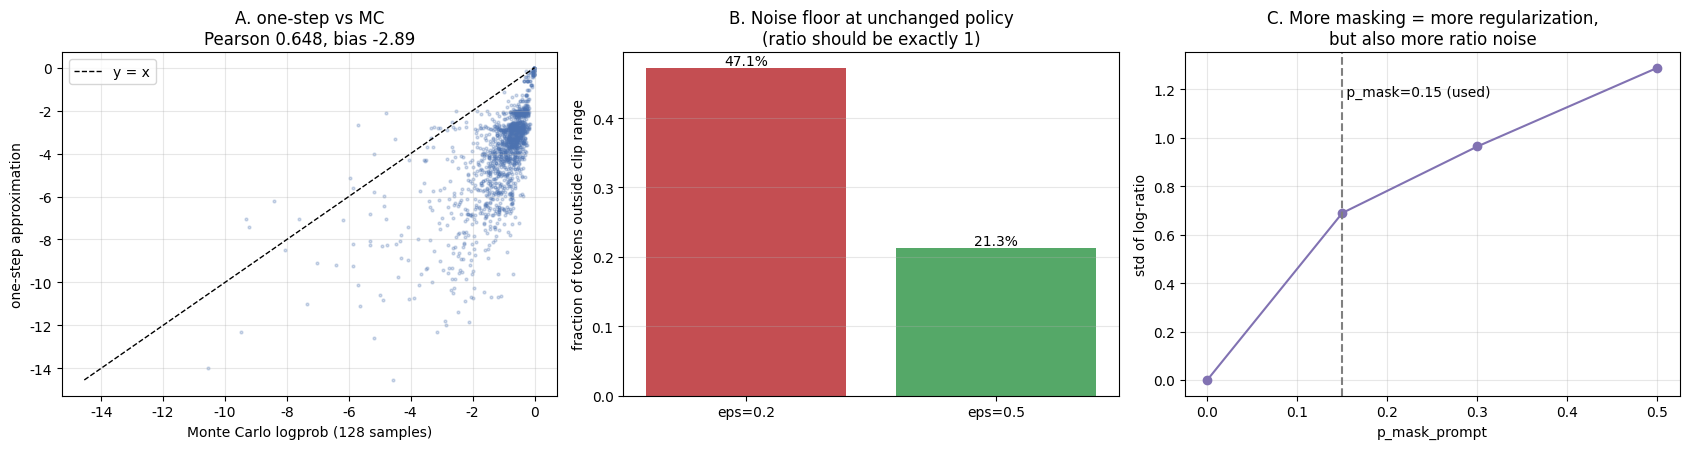

In [11]:
import csv

import numpy as np

p2 = json.loads((RESULTS / 'p2_logprob.json').read_text(encoding='utf-8'))

with open(RESULTS / 'p2_pairs.csv', encoding='utf-8') as f:
    rows = list(csv.reader(f))[1:]
pairs = np.array([[float(a), float(b)] for a, b in rows])

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# A: 单步 vs 蒙特卡洛
axes[0].scatter(pairs[:, 1], pairs[:, 0], s=4, alpha=0.25, color='#4C72B0')
lims = [min(pairs.min(), -0.5), pairs.max()]
axes[0].plot(lims, lims, 'k--', lw=1, label='y = x')
axes[0].set_xlabel('Monte Carlo logprob (128 samples)')
axes[0].set_ylabel('one-step approximation')
axes[0].set_title(
    f"A. one-step vs MC\n"
    f"Pearson {p2['experiment_a']['pearson']:.3f}, "
    f"bias {p2['experiment_a']['bias_one_step_minus_mc']:+.2f}")
axes[0].legend()
axes[0].grid(alpha=0.3)

# B: 噪声底噪 vs clip 区间
b = p2['experiment_b']
eps_keys = [k for k in b if k.startswith('out_of_range_frac_eps_')]
eps_values = sorted((float(k.rsplit('_', 1)[1]), b[k]) for k in eps_keys)
axes[1].bar([f"eps={e:g}" for e, _ in eps_values],
            [v for _, v in eps_values], color=['#C44E52', '#55A868'])
for i, (_, v) in enumerate(eps_values):
    axes[1].text(i, v, f"{v:.1%}", ha='center', va='bottom')
axes[1].set_ylabel('fraction of tokens outside clip range')
axes[1].set_title("B. Noise floor at unchanged policy\n(ratio should be exactly 1)")
axes[1].grid(alpha=0.3, axis='y')

# C: 噪声随 p_mask 变化
c = p2['experiment_c']
p_masks = sorted(float(k) for k in c)
axes[2].plot(p_masks, [c[f'{p:g}']['log_ratio_std'] for p in p_masks],
             'o-', color='#8172B2')
axes[2].axvline(0.15, ls='--', c='gray')
axes[2].text(0.15, axes[2].get_ylim()[1] * 0.9, ' p_mask=0.15 (used)', va='top')
axes[2].set_xlabel('p_mask_prompt')
axes[2].set_ylabel('std of log-ratio')
axes[2].set_title('C. More masking = more regularization,\nbut also more ratio noise')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / 'p2_logprob.png', dpi=140, bbox_inches='tight')
plt.show()

### 读这三张图

**A** 里单步估计通常系统性偏低——全掩码是信息最少的上下文，模型给不出高置信度。
但 GRPO 只用 ratio 的相对关系，绝对值偏低不致命，**相关性**才是关键。

**B** 检验的是 ε=0.5 这个乍看很奇怪的超参有没有实证依据。策略一步都没更新，
ratio 本该恒等于 1，实测的离散程度就是估计器的噪声底噪。

两种结果都要如实接受：

- 噪声大到 ε=0.2 会截掉可观比例的 token → ε 放宽有实证支持，clip 挡的应是策略跑偏而非估计噪声。
- 噪声很小 → 这组测量**不足以**支持「ε 必须放宽」。别硬往结论上靠。
  更可能的解释是噪声随 θ 真正偏离 θ_old 而放大，那要到 P3 看
  `grpo/ratio_out_of_range_frac` 随步数的变化才能验证。

**C** 说明 `p_mask_prompt` 是条权衡曲线：掩得越多正则越强、μ 才能提到 12，
但 ratio 噪声也跟着涨。`p_mask=0` 处噪声应当为 0（两次前向的输入完全相同），
这可以当作整套测量的自检。

## 7. 确认结果都在 Drive 上

P1、P2 的输出是直接写到 Drive 的，而且每完成一个阶段就落一次盘，
所以即便刚才中途断过，已经跑完的部分也还在。这里核对一遍。

In [12]:
expected = ['p1_profile.json', 'p1_metrics.csv', 'p2_logprob.json', 'p2_pairs.csv']
for name in expected:
    path = RESULTS / name
    mark = 'OK ' if path.exists() else '缺失'
    size = f"{path.stat().st_size/1024:.1f} KB" if path.exists() else '-'
    print(f"  [{mark}] {name:<20}{size:>12}")

missing = [n for n in expected if not (RESULTS / n).exists()]
if missing:
    print(f"\n缺 {missing}，把对应的单元格重跑一次即可，已有结果不会丢。")

  [OK ] p1_profile.json           5.4 KB
  [OK ] p1_metrics.csv            3.2 KB
  [OK ] p2_logprob.json           2.0 KB
  [OK ] p2_pairs.csv             58.7 KB


## 8. P3 之前：checkpoint 该怎么存

P1、P2 的输出只有几十 KB，直接写 Drive 没问题。**P3 的训练 checkpoint 不一样。**

LoRA `r=128` 挂在 LLaDA-8B 的七个投影上是 3.36 亿参数，fp32 约 1.34 GB；
加上 AdamW 的一阶、二阶矩，一个完整 checkpoint 约 **4 GB**。
Drive 是网络挂载，写入约 10-20 MB/s——存一次要 **3 到 7 分钟**，比一个训练步还慢。
每 25 步存一次的话，光存盘就能吃掉三成以上的训练时间。

所以分两级，因为两种故障的代价不同：

| | 落点 | 频率 | 救得了什么 |
|---|---|---|---|
| 本地 | `/content/checkpoints` | 每 `save_steps` 步 | 进程崩、OOM、手滑打断 |
| 镜像 | Drive | 每 `mirror_every` 次本地保存 | 会话断开、换机器 |

`trainer.resume()` 先找本地，本地没有（重连后换了机器就是这种情况）再回落到 Drive 镜像。

下面先量一次真实的存盘耗时再定频率——4GB 写 Drive 到底多慢，各人的网络不一样，
猜不如测。

## 下一步

P1、P2 的数据齐了，接下来是 P3：跑 vanilla diffu-GRPO 基线。开跑前两件事：

1. 拿第 5 节那张表定 `diffusion_steps`——它同时决定单步成本和 P4 的收益上限，
   这个权衡应该带着实测数字来定。顺便看一眼「200 步耗时」那列，
   如果超过 5 小时，先调 `max_steps` 或 `num_prompts_per_step`。
2. 拿第 8 节的实测写入速度定 `mirror_every`，并做一次恢复演练。

验证权重是否在drive上

In [15]:
import os
print('HF_HOME =', os.environ.get('HF_HOME'))
!du -sh /content/drive/MyDrive/dllm-grpo/hf-cache 2>/dev/null
!du -sh ~/.cache/huggingface 2>/dev/null

HF_HOME = /content/drive/MyDrive/dllm-grpo/hf-cache
15G	/content/drive/MyDrive/dllm-grpo/hf-cache


核对数据文件

In [16]:
import json
print(sorted(json.loads((RESULTS/'p1_profile.json').read_text())['sweep']))

['128', '64']


读取现存峰值

In [17]:
print(f"峰值 allocated {torch.cuda.max_memory_allocated()/1e9:.1f} GB  "
      f"reserved {torch.cuda.max_memory_reserved()/1e9:.1f} GB")

峰值 allocated 0.0 GB  reserved 0.0 GB
